In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import imageio

# Configurar matplotlib para mostrar imágenes en el notebook
%matplotlib inline

def show_image(img, title='', cmap=None):
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap=cmap)
    plt.axis('off')
    plt.title(title)
    plt.show()

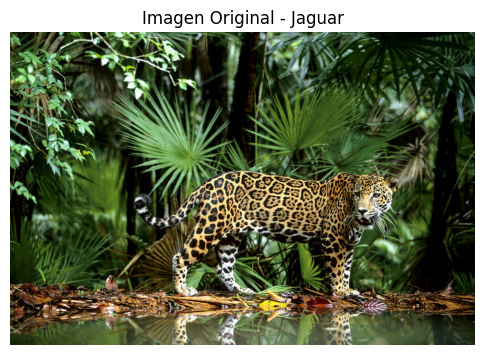

In [2]:
# 1. Carga y visualización
image_path = '/data/jaguar.jpg'
img_bgr = cv2.imread(image_path)

if img_bgr is None:
    print(f"Error: No se pudo cargar la imagen en {image_path}")
else:
    # Convertir de BGR a RGB para matplotlib
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    show_image(img_rgb, "Imagen Original - Jaguar")

## 2. Filtros Básicos (Suavizado y Realce de Bordes)

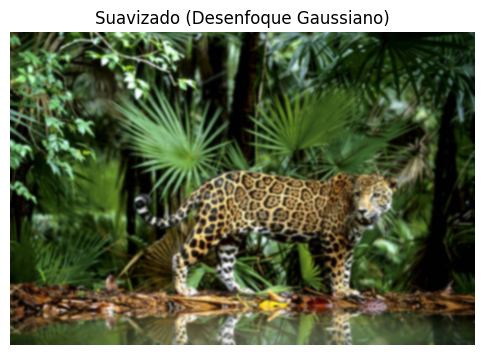

In [3]:
# Suavizado / desenfoque
img_blur = cv2.GaussianBlur(img_rgb, (11, 11), 0)
show_image(img_blur, "Suavizado (Desenfoque Gaussiano)")

El filtro de suavizado reduce el ruido y las pequeñas variaciones de color. Los bordes y detalles se ven menos definidos, dando un aspecto más "borroso" a la imagen.

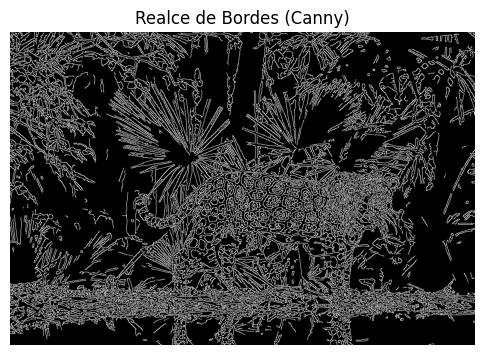

In [4]:
# Realce de bordes
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
edges = cv2.Canny(img_gray, 100, 200)
show_image(edges, "Realce de Bordes (Canny)", cmap='gray')

El filtro de realce de bordes destaca los límites entre objetos y regiones, mostrando principalmente las líneas y contornos relevantes. Permite identificar la estructura principal del jaguar y su entorno.

## 3. Visualización de Canales de Color

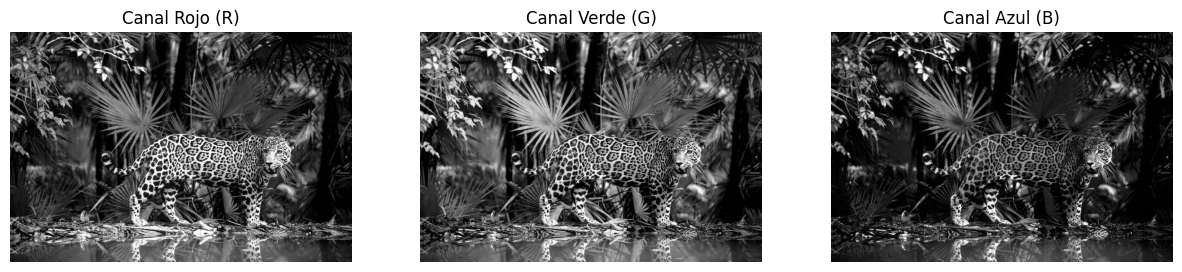

In [5]:
# Separar canales
R, G, B = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(R, cmap='gray')
axs[0].set_title('Canal Rojo (R)')
axs[0].axis('off')

axs[1].imshow(G, cmap='gray')
axs[1].set_title('Canal Verde (G)')
axs[1].axis('off')

axs[2].imshow(B, cmap='gray')
axs[2].set_title('Canal Azul (B)')
axs[2].axis('off')
plt.show()

En el **canal rojo**, las zonas claras corresponden a partes de la imagen con altas intensidades de rojo, como áreas iluminadas del pelaje del jaguar.
En el **canal verde**, las zonas claras pueden coincidir con vegetación o partes del fondo.
En el **canal azul**, generalmente las intensidades son menores; las áreas oscuras corresponden al pelaje y sombras, mientras las más claras a reflejos o puntos de luz azulada.

Las diferencias permiten identificar qué partes de la imagen son dominadas por cada componente de color.

## 4. Operaciones Morfológicas

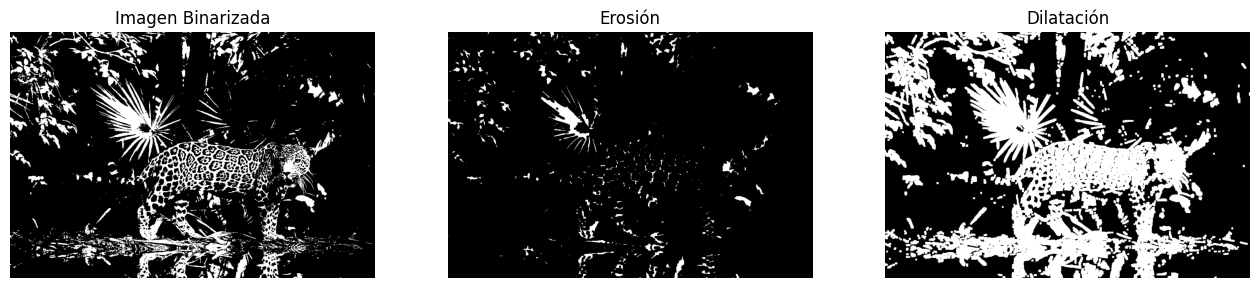

In [6]:
# Convertir a escala de grises y binarizar
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
_, img_bin = cv2.threshold(img_gray, 128, 255, cv2.THRESH_BINARY)

# Definir el elemento estructurante
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))

# Operación de erosión
eroded = cv2.erode(img_bin, kernel, iterations=1)
# Operación de dilatación
dilated = cv2.dilate(img_bin, kernel, iterations=1)

# Mostrar resultados
fig, axs = plt.subplots(1, 3, figsize=(16, 6))
axs[0].imshow(img_bin, cmap='gray')
axs[0].set_title('Imagen Binarizada')
axs[0].axis('off')

axs[1].imshow(eroded, cmap='gray')
axs[1].set_title('Erosión')
axs[1].axis('off')

axs[2].imshow(dilated, cmap='gray')
axs[2].set_title('Dilatación')
axs[2].axis('off')
plt.show()

**Erosión:** Reduce el grosor de las regiones blancas en la imagen binarizada, eliminando pequeños detalles y aislando objetos.

**Dilatación:** Aumenta el tamaño de las regiones blancas, rellenando huecos y uniendo regiones cercanas.

Estas operaciones morfológicas permiten limpiar el ruido, separar o unir objetos y preparar la imagen para análisis posteriores.

## 5. Animación (GIF)

Código añadido en el archivo generate_results.py

![Procesamiento Jaguar](python/gifs/procesamiento_jaguar.gif)